### Notebook for comparing the otsu methods, with HS vs with V as the determining spectrum
We have two implementations of the OTSU method, one that uses the Hue and Saturation of an image to find a thresholding line and one that uses Value alone of an image to find a thresholding line.

We believe that the previous method was causing a slight issue with the colour palettes and coloured dots because it was missing some of the dots systematically. Let's see if that changes when we change the thresholding approach.

Because we're running this after running binary_otsu_updated.ipynb and binary_otsu.ipynb, we should already have the outputs of this at the pathways given in those notebooks,but in case not, you can run the currently commented out cell after the import cell.

In [1]:
## Import Cell
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import puck.experiments.best_thresholding.binary_otsu_updated as bou
import puck.experiments.best_thresholding.binary_otsu as bo

In [47]:
# Commented out because you should have already run these, but left in so that you might run again if you havent' run the other notebooks. 

# output_file_dict = bo.main(
#     adjustment_on = True,
#     cli_printout = True
#     )

# output_file_dict_updated = bou.main(
#     adjustment_on = True,
#     cli_printout = True
#     )


Look at where the pipeline results are stored and grab the OTSU for both the original approach and the updated value-only approach. Choose any of these results to consider, just make sure the parameterization is the same for each so if it's (3,120,np.float(0,2)) in the original path, it needs to also be (3,120,np(0.2)) in the updated path

In [48]:
path_org = "../output/experimental_results/binary_otsu_pipeline_results/1/(3, 120, np.float64(0.2))_results.csv"
path_upd = "../output/experimental_results/binary_otsu_updated_pipeline_results/1/(3, 120, np.float64(0.2))_results.csv"

In [49]:
results_org = pd.read_csv(path_org)
results_org

,Unnamed: 0,0,1,2,3,4
0,../data/images_copy/custom/davids/high/A/custo...,11,True,False,106156125,"[0.0, 1.0, 1.0, 1.0, 506.9250437688002, 508.26..."
1,../data/images_copy/custom/davids/high/B/custo...,5,True,False,77987583,"[1.0, 1.0, 2.23606797749979, 2.23606797749979,..."
2,../data/images_copy/custom/davids/high/C/custo...,2,True,False,58979291,"[1.4142135623730951, 2.23606797749979]"
3,../data/images_copy/custom/davids/high/D/custo...,4,True,True,57561958,"[1.4142135623730951, 1.4142135623730951, 1.414..."
4,../data/images_copy/custom/davids/medium/A/cus...,4,True,True,68757875,"[1.0, 1.0, 1.0, 1.0]"
...,...,...,...,...,...,...
91,../data/images_copy/dark/michaels/medium/D/dar...,1,True,False,54028042,[2.0]
92,../data/images_copy/dark/michaels/short/A/dark...,3,True,False,43687875,"[1.0, 1.0, 2.8284271247461903]"
93,../data/images_copy/dark/michaels/short/B/dark...,4,True,True,45091625,"[1.0, 2.0, 3.1622776601683795, 3.605551275463989]"
94,../data/images_copy/dark/michaels/short/C/dark...,3,True,False,34966250,"[1.4142135623730951, 2.0, 3.0]"


In [50]:
results_upd= pd.read_csv(path_upd)
results_upd

,Unnamed: 0,0,1,2,3,4
0,data/images_copy/custom/davids/high/A/custom_d...,9,False,False,51143667,"[0.0, 1.0, 1.0, 482.8881858153086, 513.3497832..."
1,data/images_copy/custom/davids/high/B/custom_d...,5,False,False,30790917,"[1.0, 1.4142135623730951, 2.23606797749979, 30..."
2,data/images_copy/custom/davids/high/C/custom_d...,4,True,True,33059833,"[0.0, 1.4142135623730951, 2.8284271247461903, ..."
3,data/images_copy/custom/davids/high/D/custom_d...,4,True,True,38170625,"[1.4142135623730951, 1.4142135623730951, 1.414..."
4,data/images_copy/custom/davids/medium/A/custom...,3,True,False,41331834,"[1.0, 1.0, 1.0]"
...,...,...,...,...,...,...
91,data/images_copy/dark/michaels/medium/D/dark_m...,5,False,False,23419375,"[2.0, 2.0, 2.23606797749979, 5.099019513592784..."
92,data/images_copy/dark/michaels/short/A/dark_mi...,3,True,False,23241083,"[0.0, 1.0, 1.0]"
93,data/images_copy/dark/michaels/short/B/dark_mi...,2,True,False,29120334,"[1.0, 3.1622776601683795]"
94,data/images_copy/dark/michaels/short/C/dark_mi...,4,True,True,23238125,"[1.4142135623730951, 2.0, 3.0, 3.0]"


Two cleaner functions are made because the paths saved in the csvs are not quite the same, this is why inspecting them first is important. 

In the case of the original the first column is "../data/images_copy/palette/loc/height/set/path"

In the updated the first column is "data/images_copy/palette/loc/height/set/path"

Since we use "/" as a deliminator to clarify what each entry's permutation of experimental settings is, we get a different length list when cutting apart values from columns. 
If the paths change, you might need to edit these functions yet again. For now they are set up according the the previously listed differences.

In [51]:
def cleaner_org(path):
    print(path)
    df = pd.read_csv(path)
    print(df)
    df.columns =["name","blobCount", "closeEnough", "closeCount4", "time", "points"]
    df[['dots','data','images','palette', 'loc', 'height', 'set', "path"]] = df.name.str.split("/",expand=True)
    df = df.drop(["dots","data","images", "name", ], axis = 1)
    df["count4"] =(df["blobCount"] == 4)
    df_reordered = df.loc[:, ["palette", "loc", "height", "set", 'blobCount', 'closeEnough', 'count4', 'closeCount4', "time","points", "path"]] 
    cleaned = path[:-4] + "_cleaned.csv"
    df_reordered.to_csv(cleaned)
    return cleaned


In [52]:
def cleaner_upd(path):
    print(path)
    df = pd.read_csv(path)
    print(df)
    df.columns =["name","blobCount", "closeEnough", "closeCount4", "time", "points"]
    df[['data','images','palette', 'loc', 'height', 'set', "path"]] = df.name.str.split("/",expand=True)
    df = df.drop(["data","images", "name", ], axis = 1)
    df["count4"] =(df["blobCount"] == 4)
    df_reordered = df.loc[:, ["palette", "loc", "height", "set", 'blobCount', 'closeEnough', 'count4', 'closeCount4', "time","points", "path"]] 
    cleaned = path[:-4] + "_cleaned.csv"
    df_reordered.to_csv(cleaned)
    return cleaned


In [53]:
cleaned_org_results = pd.read_csv(cleaner_org(path_org))
cleaned_org_results

../output/experimental_results/binary_otsu_pipeline_results/1/(3, 120, np.float64(0.2))_results.csv
                                           Unnamed: 0   0     1      2  \
0   ../data/images_copy/custom/davids/high/A/custo...  11  True  False   
1   ../data/images_copy/custom/davids/high/B/custo...   5  True  False   
2   ../data/images_copy/custom/davids/high/C/custo...   2  True  False   
3   ../data/images_copy/custom/davids/high/D/custo...   4  True   True   
4   ../data/images_copy/custom/davids/medium/A/cus...   4  True   True   
..                                                ...  ..   ...    ...   
91  ../data/images_copy/dark/michaels/medium/D/dar...   1  True  False   
92  ../data/images_copy/dark/michaels/short/A/dark...   3  True  False   
93  ../data/images_copy/dark/michaels/short/B/dark...   4  True   True   
94  ../data/images_copy/dark/michaels/short/C/dark...   3  True  False   
95  ../data/images_copy/dark/michaels/short/D/dark...   1  True  False   

           

,Unnamed: 0,palette,loc,height,set,blobCount,closeEnough,count4,closeCount4,time,points,path
0,0,custom,davids,high,A,11,True,False,False,106156125,"[0.0, 1.0, 1.0, 1.0, 506.9250437688002, 508.26...",custom_davids_high_A_0.jpg
1,1,custom,davids,high,B,5,True,False,False,77987583,"[1.0, 1.0, 2.23606797749979, 2.23606797749979,...",custom_davids_high_B_0.jpg
2,2,custom,davids,high,C,2,True,False,False,58979291,"[1.4142135623730951, 2.23606797749979]",custom_davids_high_C_0.jpg
3,3,custom,davids,high,D,4,True,True,True,57561958,"[1.4142135623730951, 1.4142135623730951, 1.414...",custom_davids_high_D_0.jpg
4,4,custom,davids,medium,A,4,True,True,True,68757875,"[1.0, 1.0, 1.0, 1.0]",custom_davids_medium_A_0.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...
91,91,dark,michaels,medium,D,1,True,False,False,54028042,[2.0],dark_michaels_medium_D_0.jpg
92,92,dark,michaels,short,A,3,True,False,False,43687875,"[1.0, 1.0, 2.8284271247461903]",dark_michaels_short_A_0.jpg
93,93,dark,michaels,short,B,4,True,True,True,45091625,"[1.0, 2.0, 3.1622776601683795, 3.605551275463989]",dark_michaels_short_B_0.jpg
94,94,dark,michaels,short,C,3,True,False,False,34966250,"[1.4142135623730951, 2.0, 3.0]",dark_michaels_short_C_0.jpg


In [54]:
cleaned_upd_results = pd.read_csv(cleaner_upd(path_upd))
cleaned_upd_results

../output/experimental_results/binary_otsu_updated_pipeline_results/1/(3, 120, np.float64(0.2))_results.csv
                                           Unnamed: 0  0      1      2  \
0   data/images_copy/custom/davids/high/A/custom_d...  9  False  False   
1   data/images_copy/custom/davids/high/B/custom_d...  5  False  False   
2   data/images_copy/custom/davids/high/C/custom_d...  4   True   True   
3   data/images_copy/custom/davids/high/D/custom_d...  4   True   True   
4   data/images_copy/custom/davids/medium/A/custom...  3   True  False   
..                                                ... ..    ...    ...   
91  data/images_copy/dark/michaels/medium/D/dark_m...  5  False  False   
92  data/images_copy/dark/michaels/short/A/dark_mi...  3   True  False   
93  data/images_copy/dark/michaels/short/B/dark_mi...  2   True  False   
94  data/images_copy/dark/michaels/short/C/dark_mi...  4   True   True   
95  data/images_copy/dark/michaels/short/D/dark_mi...  4   True   True   

   

,Unnamed: 0,palette,loc,height,set,blobCount,closeEnough,count4,closeCount4,time,points,path
0,0,custom,davids,high,A,9,False,False,False,51143667,"[0.0, 1.0, 1.0, 482.8881858153086, 513.3497832...",custom_davids_high_A_0.jpg
1,1,custom,davids,high,B,5,False,False,False,30790917,"[1.0, 1.4142135623730951, 2.23606797749979, 30...",custom_davids_high_B_0.jpg
2,2,custom,davids,high,C,4,True,True,True,33059833,"[0.0, 1.4142135623730951, 2.8284271247461903, ...",custom_davids_high_C_0.jpg
3,3,custom,davids,high,D,4,True,True,True,38170625,"[1.4142135623730951, 1.4142135623730951, 1.414...",custom_davids_high_D_0.jpg
4,4,custom,davids,medium,A,3,True,False,False,41331834,"[1.0, 1.0, 1.0]",custom_davids_medium_A_0.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...
91,91,dark,michaels,medium,D,5,False,False,False,23419375,"[2.0, 2.0, 2.23606797749979, 5.099019513592784...",dark_michaels_medium_D_0.jpg
92,92,dark,michaels,short,A,3,True,False,False,23241083,"[0.0, 1.0, 1.0]",dark_michaels_short_A_0.jpg
93,93,dark,michaels,short,B,2,True,False,False,29120334,"[1.0, 3.1622776601683795]",dark_michaels_short_B_0.jpg
94,94,dark,michaels,short,C,4,True,True,True,23238125,"[1.4142135623730951, 2.0, 3.0, 3.0]",dark_michaels_short_C_0.jpg


A random seed is chosen so that we can apply a slight adjustment to all the blob counts, not very high but a random offset that you control. This allows us to make a nice swarmplot and keeps the dots from being overlapping and confusing. You can see things much more clearly this way.

I've plotted this twice, once for the original OTSU and once for the updated OTSU to examine how the palettes are distributed at different blob counts across permutations.
We expect to have about 4 blobs, but do not expect there to be any grouping between the palettes. If there is clear grouping between custom and dark, this is a sign that the method might be biased towards certain palettes and their colours. Ideally custom and dark should be intermixed on both graphs.

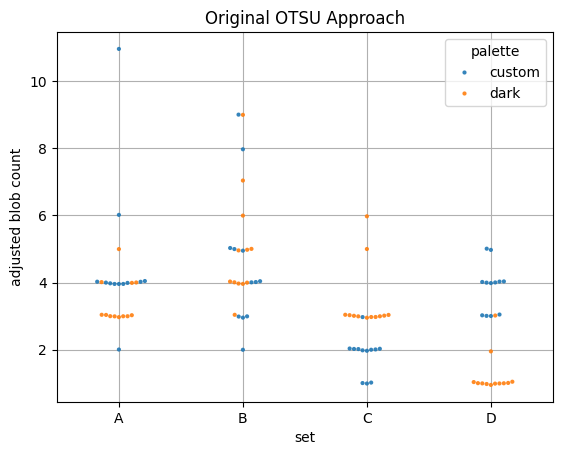

In [55]:
random.seed(2026)
adjust  =ran_floats = [random.uniform(-.05,.05) for _ in range(len(cleaned_org_results["blobCount"] ))]
cleaned_org_results["adjusted blob count"] = cleaned_org_results["blobCount"] + adjust
sns.swarmplot(data=cleaned_org_results, x="set", y="adjusted blob count", hue= "palette", alpha = .9, size = 3)
plt.title("Original OTSU Approach")
plt.grid()
plt.show()


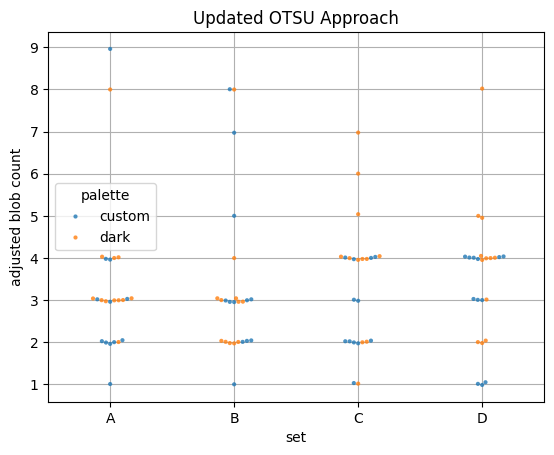

In [56]:
random.seed(2026)
adjust  =ran_floats = [random.uniform(-.05,.05) for _ in range(len(cleaned_upd_results["blobCount"] ))]
cleaned_upd_results["adjusted blob count"] = cleaned_upd_results["blobCount"] + adjust
sns.swarmplot(data=cleaned_upd_results, x="set", y="adjusted blob count", hue= "palette", alpha = .8, size = 3)
plt.title("Updated OTSU Approach")
plt.grid()
plt.show()

We can see the clearest seperation in permutation C where there is a pretty strict line in blob count between the custom and dark palettes in the original approach. This likely means that palette is acting as a factor in the OTSU dot finding method. Because we want it to work regardless of palette choice, we should go with the updated approach where palette is more intermixed and a lot more of the images are finding exactly 4 dots as compared to the original.

If we collapse the permutation division and graph out the distribution of blobcounts between approaches, what do we get?

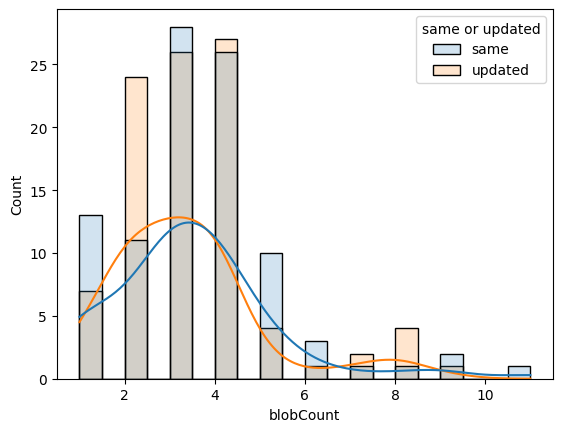

In [67]:
cleaned_org_results["same or updated"] = "same"
cleaned_upd_results["same or updated"] = "updated"
jointResults = pd.concat([cleaned_org_results, cleaned_upd_results])
sns.histplot(data= jointResults, x="blobCount", hue = "same or updated", kde=True, binwidth= .5, alpha = .2,kde_kws= {"bw_adjust": 1}) 
plt.show()


Looks like the original approach is centered around 3, which tracks with the discrepancy seen in permutation C, and the updated approach is more centered around 4. Both are centered near the same spot though and exhibit right tailed distributions.